# Simple Object Detection with CNN - Bounding Box Prediction Tutorial

This tutorial demonstrates how to build a simple object detection model using a pre-trained ResNet34 architecture to predict bounding boxes for bird images from the CUB-200 dataset. The model will learn to localize objects by predicting the (x, y, width, height) of bounding boxes.

## Key Concepts:
- **Transfer Learning**: Using a pre-trained ResNet34 model
- **Bounding Box Regression**: Predicting object locations as regression targets
- **Intersection over Union (IoU)**: Evaluating bounding box prediction accuracy
- **Data Augmentation**: Improving model generalization with augmentation techniques

## 1. Import Required Libraries and Set Random Seeds

In [1]:
# Import core libraries
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader as dataloader
import torchvision.models as models

# Import augmentation and utilities
import albumentations as A
from albumentations.pytorch import ToTensorV2
import kagglehub
import shutil
import time
import os
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image, ImageOps
import copy
import pandas as pd

# Import custom modules
from Trainer import ModelTrainer
from Datasets import CUB200

# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"✓ All imports loaded")
print(f"✓ Random seeds set to {SEED}")

/home/caokhoa/Documents/CV-Research/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports loaded
✓ Random seeds set to 42


In [2]:
# Training hyperparameters
batch_size = 64
num_epochs = 50
learning_rate = 1e-4

# Dataset configuration (stored next to this notebook)
data_set_root = "./datasets"
image_size = 128

# Model checkpoint
start_from_checkpoint = False
overwrite_checkpoint = True  # If True, will overwrite existing checkpoint
save_dir = 'Checkpoints'
model_name = 'ResNet34_CUB'

# GPU/CPU setup
gpu_indx = 0
device = torch.device(f'cuda:{gpu_indx}' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


## 2. Configure Hyperparameters, Dataset & Device

In [3]:
print("Downloading CUB-200-2011 dataset from Kaggle...")

try:
    kaggle_path = kagglehub.dataset_download("wenewone/cub2002011")

    # Find notebook directory (supports running from project root or the notebook folder)
    candidate_dirs = [
        os.getcwd(),
        os.path.join(os.getcwd(), "Basics"),
    ]
    notebook_dir = None
    for d in candidate_dirs:
        if os.path.exists(os.path.join(d, "Simple_object_detection_with_CNN.ipynb")):
            notebook_dir = d
            break
    if notebook_dir is None:
        notebook_dir = os.getcwd()

    datasets_root = os.path.join(notebook_dir, "datasets")
    target_root = os.path.join(datasets_root, "CUB_200_2011")

    if os.path.exists(target_root):
        shutil.rmtree(target_root)
    os.makedirs(datasets_root, exist_ok=True)

    # Ensure structure: datasets/CUB_200_2011/CUB_200_2011/*.txt
    inner_dir = os.path.join(kaggle_path, "CUB_200_2011")
    if os.path.exists(inner_dir):
        shutil.copytree(inner_dir, target_root)
    else:
        shutil.copytree(kaggle_path, target_root)

    print(f"✓ Dataset saved to: {target_root}")
    print(f"✓ Total items: {len(os.listdir(target_root))}")

except Exception as e:
    print(f"Error: {e}")
    print("Make sure kagglehub is installed and Kaggle API is configured")

✓ Dataset saved to: /home/caokhoa/Documents/CV-Research/Basics/datasets/CUB_200_2011
✓ Total items: 9


## 3. Download and Organize Dataset from Kaggle

In [4]:
# Data augmentation for training
train_transform = A.Compose([
    A.SmallestMaxSize(max_size=image_size),
    A.RandomCrop(height=image_size, width=image_size),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='coco', min_area=0, min_visibility=0.0, label_fields=['class_labels']))

# Data augmentation for validation/test
test_transform = A.Compose([
    A.SmallestMaxSize(max_size=image_size),
    A.RandomCrop(height=image_size, width=image_size),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='coco', min_area=0, min_visibility=0.0, label_fields=['class_labels']))

/home/caokhoa/Documents/CV-Research/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 4. Define Data Augmentation Transformations

In [5]:
# Load training and test data
train_data = CUB200(data_set_root, image_size=image_size, transform=train_transform, test_train=0)
test_data = CUB200(data_set_root, image_size=image_size, transform=test_transform, test_train=1)

# Split training data: 90% train, 10% validation
validation_split = 0.9
n_train_examples = int(len(train_data) * validation_split)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = torch.utils.data.random_split(
    train_data, [n_train_examples, n_valid_examples],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_data)}, Val: {len(valid_data)}, Test: {len(test_data)}")

Train: 5394, Val: 600, Test: 5794


## 5. Load and Prepare Datasets

In [6]:
# Define Intersection over Union (IoU) metric
class BboxIOU(nn.Module):
    """Computes IoU for bounding box predictions"""
    
    def xyhw_to_xyxy(self, bbox):
        """Convert (x, y, w, h) to (x_min, y_min, x_max, y_max) format"""
        return torch.cat((bbox[:, 0:1], bbox[:, 1:2],
                          bbox[:, 2:3] + bbox[:, 0:1],
                          bbox[:, 3:4] + bbox[:, 1:2]), 1)

    def bb_intersection_over_union(self, pred_xyhw, target_xyhw):
        """Calculate IoU between predicted and target bounding boxes"""
        pred_xyxy = self.xyhw_to_xyxy(pred_xyhw)
        target_xyxy = self.xyhw_to_xyxy(target_xyhw)

        # Intersection rectangle
        xA = torch.cat((pred_xyxy[:, 0:1], target_xyxy[:, 0:1]), 1).max(dim=1)[0].unsqueeze(1)
        yA = torch.cat((pred_xyxy[:, 1:2], target_xyxy[:, 1:2]), 1).max(dim=1)[0].unsqueeze(1)
        xB = torch.cat((pred_xyxy[:, 2:3], target_xyxy[:, 2:3]), 1).min(dim=1)[0].unsqueeze(1)
        yB = torch.cat((pred_xyxy[:, 3:4], target_xyxy[:, 3:4]), 1).min(dim=1)[0].unsqueeze(1)

        # Intersection and union
        x_len = F.relu(xB - xA)
        y_len = F.relu(yB - yA)
        interArea = x_len * y_len
        
        area1 = pred_xyhw[:, 2:3] * pred_xyhw[:, 3:4]
        area2 = target_xyhw[:, 2:3] * target_xyhw[:, 3:4]
        iou = interArea / (area1 + area2 - interArea + 1e-5)

        return iou

    def forward(self, predictions, data):
        pred_bbox = torch.sigmoid(predictions[:, :4])
        target_bbox = data[1].to(pred_bbox.device)
        return self.bb_intersection_over_union(pred_bbox, target_bbox)

## 6. Define IoU Evaluation Metric

In [7]:
# Initialize ResNet34 model
res_net = models.resnet34(weights="IMAGENET1K_V1")
print("ResNet34 model loaded (pre-trained on ImageNet 1K)")

# Create model trainer
model_trainer = ModelTrainer(
    model=res_net.to(device),
    output_size=4,
    device=device,
    loss_fun=nn.BCEWithLogitsLoss(),
    batch_size=batch_size,
    learning_rate=learning_rate,
    save_dir=save_dir,
    model_name=model_name,
    start_from_checkpoint=start_from_checkpoint,
    eval_metric=BboxIOU(),
)

# Set data and learning rate scheduler
model_trainer.set_data(train_set=train_data, test_set=test_data, val_set=valid_data)
model_trainer.set_lr_schedule(optim.lr_scheduler.StepLR(model_trainer.optimizer, step_size=1, gamma=0.95))

print("Model trainer initialized!")

ResNet34 model loaded (pre-trained on ImageNet 1K)
Starting from scratch
Number of training examples: 5394
Number of validation examples: 600
Number of testing examples: 5794
Model trainer initialized!


/home/caokhoa/Documents/CV-Research/Basics/Trainer.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


## 7. Visualize Training Data with Bounding Boxes

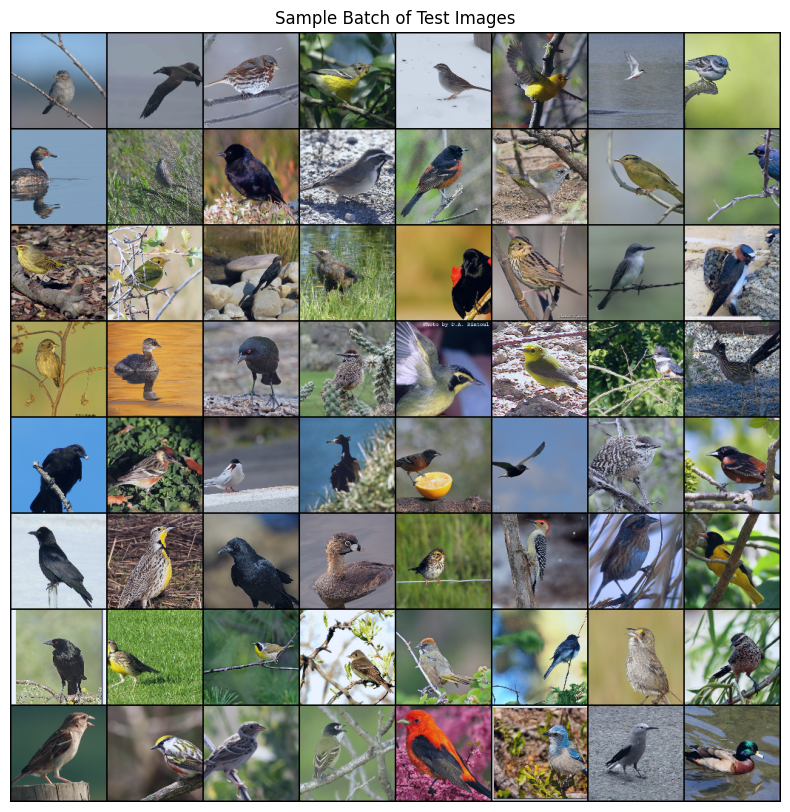

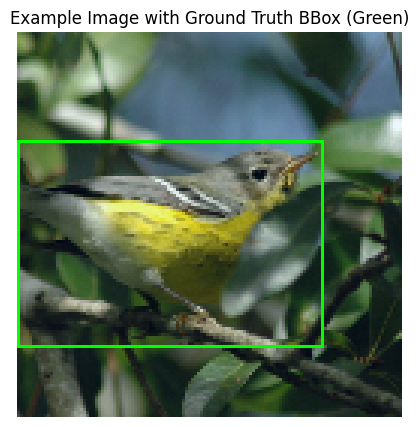

In [8]:
# Visualize training data
plt.figure(figsize=(20, 10))
images, bbox, labels = next(iter(model_trainer.test_loader))
out = torchvision.utils.make_grid(images, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))
plt.title("Sample Batch of Test Images")
plt.axis('off')
plt.show()

# View single image with bounding box
example_indx = 3
ex_img = images[example_indx]
ex_label = bbox[example_indx].unsqueeze(0) * image_size
ex_label[:, 2] += ex_label[:, 0]
ex_label[:, 3] += ex_label[:, 1]

img_out = (((ex_img - ex_img.min()) / (ex_img.max() - ex_img.min())) * 255).to(torch.uint8)
img_box = torchvision.utils.draw_bounding_boxes(img_out, ex_label, colors=(0, 255, 0))

plt.figure(figsize=(5, 5))
out = torchvision.utils.make_grid(img_box.unsqueeze(0).float(), normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))
plt.title("Example Image with Ground Truth BBox (Green)")
plt.axis('off')
plt.show()

## 8. Model Architecture Overview

In [9]:
# Count model parameters
num_params = sum(p.flatten().shape[0] for p in model_trainer.model.parameters())
print(f"Model Parameters: {num_params:,} ({num_params / 1e6:.2f}M)")

Model Parameters: 21,286,724 (21.29M)


## 9. Train the Model

In [10]:
import datetime
from pathlib import Path
import os

# Display configuration
print("🔒 Deterministic mode ENABLED (Reproducibility optimized). Benchmark mode DISABLED.")
print("🚀 Configuration:")
print(f"   EPOCHS: {num_epochs}")
print(f"   BATCH_SIZE: {batch_size}")
print(f"   LEARNING_RATE: {learning_rate}")
print(f"   DEVICE: {device}")
print(f"   IMAGE_SIZE: {image_size}")
print(f"   MODEL: {model_name}")
print(f"   OVERWRITE: {overwrite_checkpoint}")

# Display dataset info
print(f"\n📊 Dataset Information:")
print(f"   Train Samples: {n_train_examples:,}")
print(f"   Validation Samples: {n_valid_examples:,}")
print(f"   Test Samples: {len(test_data):,}")

# Display model info
num_params = sum(p.flatten().shape[0] for p in model_trainer.model.parameters())
trainable_params = sum(p.flatten().shape[0] for p in model_trainer.model.parameters() if p.requires_grad)
print(f"\n📊 Model ({model_name}): {num_params:,} total params, {trainable_params:,} trainable")

# Handle checkpoint overwrite
overwrite_checkpoint = True  # Set to True to enable overwriting existing checkpoints
checkpoint_path = os.path.join(save_dir, model_name + ".pt")
if os.path.isfile(checkpoint_path):
    if overwrite_checkpoint:
        print(f"\n⚠️  Checkpoint exists at {checkpoint_path}")
        print(f"🔄 OVERWRITE MODE: Removing old checkpoint...")
        os.remove(checkpoint_path)
        print(f"✓ Old checkpoint removed. Starting fresh training.\n")
    else:
        print(f"\n⚠️  WARNING: Checkpoint exists at {checkpoint_path}")
        print(f"Set 'overwrite_checkpoint = True' to overwrite it.\n")

print(f"🚀 TRAINING START | Device: {device} | Epochs: {num_epochs}\n")

# Run training
model_trainer.run_training(num_epochs=num_epochs)

print("\n✅ Training completed!")

🔒 Deterministic mode ENABLED (Reproducibility optimized). Benchmark mode DISABLED.
🚀 Configuration:
   EPOCHS: 50
   BATCH_SIZE: 64
   LEARNING_RATE: 0.0001
   DEVICE: cuda:0
   IMAGE_SIZE: 128
   MODEL: ResNet34_CUB
   OVERWRITE: True

📊 Dataset Information:
   Train Samples: 5,394
   Validation Samples: 600
   Test Samples: 5,794

📊 Model (ResNet34_CUB): 21,286,724 total params, 21,286,724 trainable
🚀 TRAINING START | Device: cuda:0 | Epochs: 50



Epoch 50/50: 100%|██████████| 50/50 [13:10<00:00, 15.80s/it, LR: 8.10e-06 | Train Loss: 0.4555 | Train Acc: 0.8738 | Val Acc: 0.8417]


✅ Training completed!


## 10. Analyze Training Results

## Load Pre-trained Model from Checkpoint

In [15]:
import os
import torch
import torchvision.models as models
from Trainer import ModelTrainer

# Configuration
checkpoint_path = 'Checkpoints/ResNet34_CUB.pt'  # Path to your checkpoint
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Initialize model (same architecture as training)
res_net = models.resnet34(weights="IMAGENET1K_V1")

# Create trainer instance with start_from_checkpoint=True
model_trainer = ModelTrainer(
    model=res_net.to(device),
    output_size=4,
    device=device,
    loss_fun=torch.nn.BCEWithLogitsLoss(),
    batch_size=64,
    learning_rate=1e-4,
    save_dir='Checkpoints',
    model_name='ResNet34_CUB',
    start_from_checkpoint=True,  # Load from checkpoint
    eval_metric=BboxIOU(),
)

# Load dataset for evaluation
model_trainer.set_data(train_set=train_data, test_set=test_data, val_set=valid_data)

print(f"✓ Model loaded from: {checkpoint_path}")
print(f"✓ Best validation accuracy: {model_trainer.best_valid_acc*100:.2f}%")
print(f"✓ Model is ready for inference/evaluation")

Checkpoint loaded, starting from epoch: 44
Number of training examples: 5394
Number of validation examples: 600
Number of testing examples: 5794
✓ Model loaded from: Checkpoints/ResNet34_CUB.pt
✓ Best validation accuracy: 84.24%
✓ Model is ready for inference/evaluation


Best Validation IoU: 0.8424


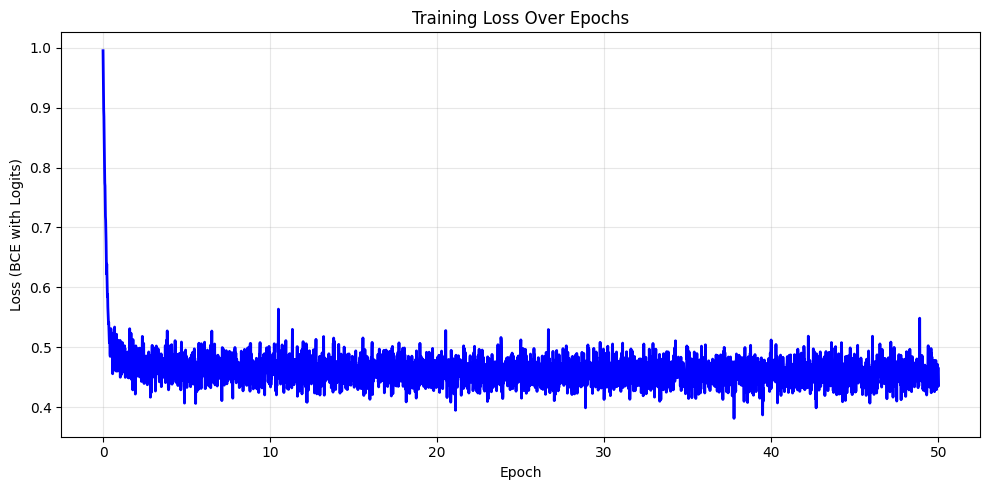

Initial Loss: 0.9951
Final Loss: 0.4364


In [16]:
# Analyze training results
print(f"Best Validation IoU: {model_trainer.best_valid_acc:.4f}")

plt.figure(figsize=(10, 5))
train_x = np.linspace(0, num_epochs, len(model_trainer.train_loss_logger))
plt.plot(train_x, model_trainer.train_loss_logger, linewidth=2, color='blue')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE with Logits)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {model_trainer.train_loss_logger[0]:.4f}")
print(f"Final Loss: {model_trainer.train_loss_logger[-1]:.4f}")

## 11. Visualize Training vs Validation Metrics

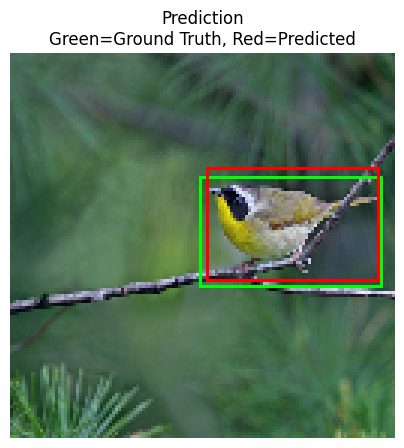

In [17]:
# Test model predictions
example_indx = 50
ex_img = images[example_indx]
img_out = (((ex_img - ex_img.min()) / (ex_img.max() - ex_img.min())) * 255).to(torch.uint8)

real_label = bbox[example_indx].unsqueeze(0) * image_size
real_label[:, 2] += real_label[:, 0]
real_label[:, 3] += real_label[:, 1]

model_trainer.eval()
with torch.no_grad():
    pred_out = torch.sigmoid(model_trainer(ex_img.unsqueeze(0).to(device)))
    pred_label = (pred_out * image_size).cpu()
    pred_label[:, 2] += pred_label[:, 0]
    pred_label[:, 3] += pred_label[:, 1]

img_box = torchvision.utils.draw_bounding_boxes(img_out, real_label, colors=(0, 255, 0))
img_box = torchvision.utils.draw_bounding_boxes(img_box, pred_label, colors=(255, 0, 0))

plt.figure(figsize=(5, 5))
out = torchvision.utils.make_grid(img_box.unsqueeze(0).float(), normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))
plt.title("Prediction\nGreen=Ground Truth, Red=Predicted")
plt.axis('off')
plt.show()

## 12. Test Model Predictions

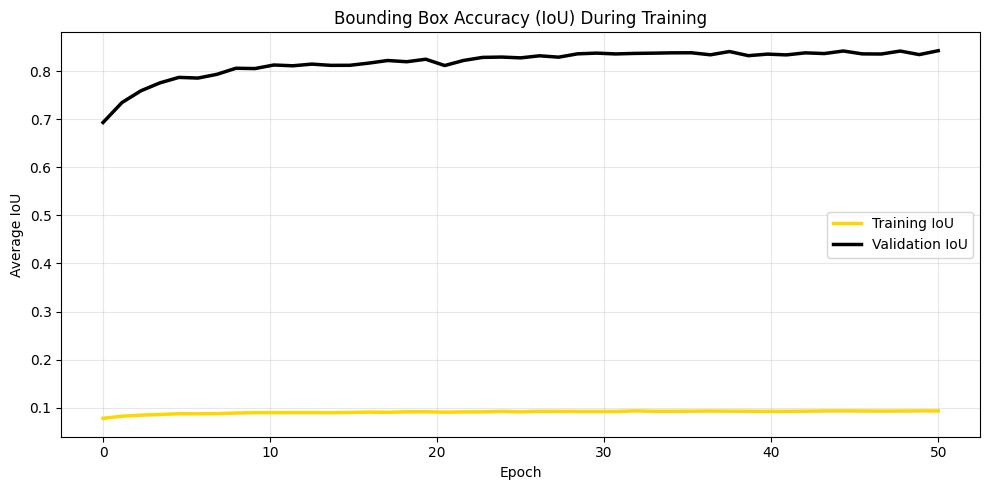

Max Train IoU: 0.0936 | Max Val IoU: 0.8424


In [18]:
# Plot training vs validation IoU
plt.figure(figsize=(10, 5))

train_x = np.linspace(0, num_epochs, len(model_trainer.train_acc_logger))
plt.plot(train_x, model_trainer.train_acc_logger, color='gold', linewidth=2.5, label='Training IoU')

valid_x = np.linspace(0, num_epochs, len(model_trainer.val_acc_logger))
plt.plot(valid_x, model_trainer.val_acc_logger, color='black', linewidth=2.5, label='Validation IoU')

plt.title("Bounding Box Accuracy (IoU) During Training")
plt.xlabel("Epoch")
plt.ylabel("Average IoU")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

max_train_iou = max(model_trainer.train_acc_logger)
max_val_iou = max(model_trainer.val_acc_logger)
print(f"Max Train IoU: {max_train_iou:.4f} | Max Val IoU: {max_val_iou:.4f}")

## 13. Final Evaluation on Test Set

In [14]:
# Final evaluation on test set
print("Evaluating on test set...")
test_acc = model_trainer.evaluate_model(train_test_val="test")

print(f"\nTest Set Average IoU: {test_acc:.4f}")
print(f"Best Validation IoU: {model_trainer.best_valid_acc:.4f}")

if test_acc > 0.75:
    print("✓ Excellent performance!")
elif test_acc > 0.6:
    print("✓ Good performance!")
else:
    print("⚠ Fair performance - could improve with more training")

Evaluating on test set...



Test Set Average IoU: 0.8357
Best Validation IoU: 0.8462
✓ Excellent performance!


## Summary & Results

## 14. Training on Google Colab / Kaggle

To train on Google Colab or Kaggle, follow these steps:

### Setup Instructions:

1. **Push to GitHub** (from terminal):
```bash
cd /path/to/CV-Research
git init
git add .
git commit -m "Initial commit"
git remote add origin https://github.com/YOUR_USERNAME/CV-Research.git
git branch -M main
git push -u origin main
```

2. **In Colab notebook**, run these cells:

```python
# Clone repository
!git clone https://github.com/YOUR_USERNAME/CV-Research.git
%cd CV-Research

# Install dependencies (if needed)
!pip install -q torch torchvision torchaudio
!pip install -q albumentations kagglehub
```

3. **Download dataset on Colab**:
```python
# Configure Kaggle API first (upload kaggle.json to Colab)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Then download
!python -c "from Basics.Datasets import CUB200; CUB200('./Basics/datasets', test_train=0)"
```

### Running train.py with Custom Dataset Path:

**On Colab/Kaggle**, if your dataset is in a different location:

```python
# If dataset is at Kaggle input: /kaggle/input/cub-200-2011/
!cd Basics && python train.py \
    --data-root /kaggle/input/cub-200-2011 \
    --epochs 50 \
    --batch-size 64 \
    --learning-rate 1e-4 \
    --overwrite
```

**On Local Machine**:
```bash
# If dataset is at ./datasets
cd Basics
python train.py --epochs 50 --batch-size 64 --overwrite

# If dataset is elsewhere
python train.py \
    --data-root /path/to/dataset \
    --epochs 50 \
    --batch-size 64 \
    --overwrite
```

### All Available Arguments for train.py:

```
--epochs INT              Number of epochs (default: 50)
--batch-size INT          Batch size (default: 64)
--learning-rate FLOAT     Learning rate (default: 0.0001)
--image-size INT          Image size (default: 128)
--data-root PATH          Path to dataset folder (default: ./datasets)
--model-name STR          Checkpoint name (default: ResNet34_CUB)
--save-dir PATH           Checkpoint save directory (default: ../Checkpoints)
--gpu INT                 GPU index (default: 0)
--overwrite               Remove and restart training (no checkpoint continuation)
--start-from-checkpoint   Continue training from saved checkpoint
```

### Example Commands:

**Kaggle with custom dataset path:**
```python
!cd Basics && python train.py --data-root /kaggle/input/cub-200 --epochs 30 --batch-size 32 --overwrite
```

**Local with different batch size:**
```bash
python train.py --data-root /mnt/data/CUB --batch-size 128 --epochs 100
```

**Continue training from checkpoint:**
```bash
python train.py --data-root ./datasets --start-from-checkpoint
```

5. **Download checkpoints** (on Colab):
```python
from google.colab import files
files.download('../Checkpoints/ResNet34_CUB.pt')
```
